# Sistema de Riego Inteligente — Entrenamiento TinyMLClasificador de 3 clases

## 0. Librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Muestra todas las columnas al visualizar DataFrames
pd.set_option('display.max_columns', None)

## 1. Carga de datos### 1.1 Dataset principal (recolección de 5 días, ~5000 muestras)

In [3]:
from google.colab import files

# Carga el archivo CSV desde el entorno de Google Colab
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f"Filas cargadas: {len(df)}")
print(f"Columnas: {list(df.columns)}")

Saving dataset_riego_etiquetado_entrenar.csv to dataset_riego_etiquetado_entrenar.csv
Filas cargadas: 4998
Columnas: ['ts_real', 'ts_esp32', 'soil_raw', 'temp', 'hum', 'estado', 'momento', 'label']


### 1.2 Dataset de validación adicional (sesión anterior, 180 muestras)

In [4]:
# Carga el conjunto de datos de prueba desde Google Colab
uploaded2 = files.upload()
filename2 = list(uploaded2.keys())[0]
real = pd.read_csv(filename2)

print(f"Filas cargadas: {len(real)}")

Saving dataset_riego_etiquetado_prueba.csv to dataset_riego_etiquetado_prueba.csv
Filas cargadas: 180


## 2. Preparación: mapeo a 3 clases finales

**Criterio de riego definido:**- `SECO` → necesita riego- `OPTIMO` (humedo + humedo-mojado) → rango correcto, sin acción- `SATURADO` (mojado) → exceso de agua, alerta

**Importante:** se etiqueta con la columna `estado` (observación física real), NUNCA con una columna `label` que venga de un umbral — el umbral simple demostró tener ~15% de error en la frontera SECO/OPTIMO por efecto de la temperatura (ver sección 3).

In [5]:
# Agrupa los estados originales en tres clases de humedad
mapa_clases = {
    'seco': 'SECO',
    'humedo': 'OPTIMO',
    'humedo-mojado': 'OPTIMO',
    'mojado': 'SATURADO'
}

df['label_real'] = df['estado'].map(mapa_clases)
real['label_real'] = real['estado'].map(mapa_clases)

print("Distribucion dataset principal:")
print(df['label_real'].value_counts())

print("\nDistribucion dataset de validacion:")
print(real['label_real'].value_counts())

Distribucion dataset principal:
label_real
SATURADO    1666
OPTIMO      1666
SECO        1666
Name: count, dtype: int64

Distribucion dataset de validacion:
label_real
OPTIMO      90
SATURADO    46
SECO        44
Name: count, dtype: int64


## 3. Análisis exploratorio

### 3.1 Estadísticas por clase

In [6]:
# Resume las características estadísticas de cada clase de humedad
print(
    df.groupby('label_real')[['soil_raw', 'temp', 'hum']]
      .agg(['mean', 'std', 'min', 'max'])
      .round(1)
)

# Calcula la correlación entre las variables numéricas
print("\nCorrelacion entre variables:")
print(df[['soil_raw', 'temp', 'hum']].corr().round(3))

           soil_raw                     temp                    hum       \
               mean    std   min   max  mean  std   min   max  mean  std   
label_real                                                                 
OPTIMO       1478.0  212.6   600  2511  19.0  5.5  13.4  31.6  29.2  8.2   
SATURADO     1003.4   68.9   846  1224  18.7  5.2  13.3  30.5  29.8  8.2   
SECO         2193.6  452.6  1505  3056  18.4  4.5  13.6  26.7  29.2  7.3   

                        
             min   max  
label_real              
OPTIMO      18.7  41.8  
SATURADO    21.2  42.0  
SECO        21.2  41.5  

Correlacion entre variables:
          soil_raw   temp    hum
soil_raw     1.000  0.286 -0.038
temp         0.286  1.000 -0.584
hum         -0.038 -0.584  1.000


### 3.2 Separabilidad visual: soil_raw vs temperatura

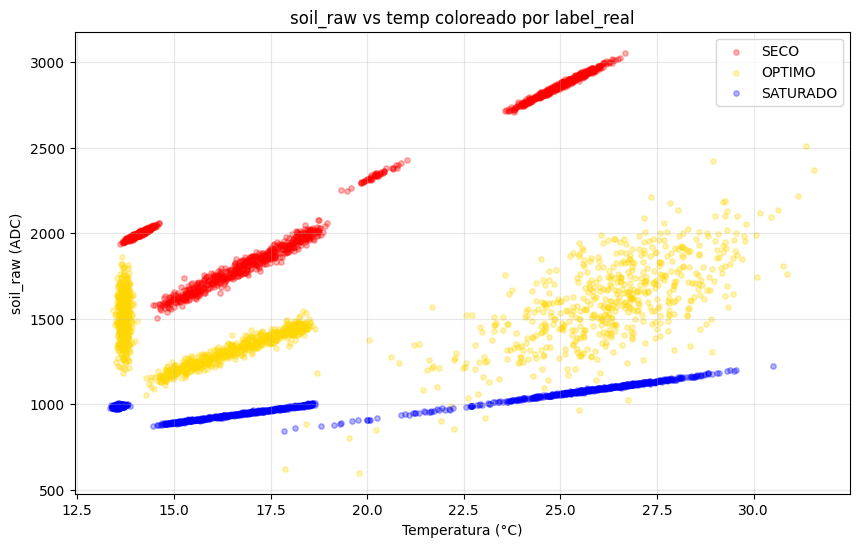

In [7]:
plt.figure(figsize=(10, 6))

colores = {'SECO': 'red', 'OPTIMO': 'gold', 'SATURADO': 'blue'}

# Iteramos para graficar los puntos
for label, color in colores.items():
    subset = df[df['label_real'] == label]
    plt.scatter(subset['temp'], subset['soil_raw'], c=color, label=label, alpha=0.3, s=15)

# Configuraciones fuera del bucle para que se apliquen al gráfico final
plt.xlabel('Temperatura (°C)')
plt.ylabel('soil_raw (ADC)')
plt.title('soil_raw vs temp coloreado por label_real')
plt.legend()
plt.grid(alpha=0.3)

# Mostrar el gráfico una sola vez al terminar
plt.show()

## 4. Modelo baseline (Logistic Regression)
Validación rápida: ¿mejora el accuracy al usar `soil_raw + temp + hum` frente a usar solo `soil_raw`? (Ya confirmado: sí, 92% vs 79% en el dataset de validación externo.)

### 4.1 Split temporal (por día, evita data leakage)

In [8]:
# Separa el último día disponible como conjunto de prueba
df['fecha'] = pd.to_datetime(df['ts_real']).dt.date
dias_unicos = sorted(df['fecha'].unique())

dia_test = dias_unicos[-1]
train_df = df[df['fecha'] != dia_test].copy()
test_df = df[df['fecha'] == dia_test].copy()

print(f"Train: {len(train_df)} | Test: {len(test_df)} (dia {dia_test})")

Train: 4981 | Test: 17 (dia 2026-07-22)


### 4.2 Entrenamiento: 3 features vs 1 feature

In [9]:
features = ['soil_raw', 'temp', 'hum']

# Entrena un modelo usando las tres variables disponibles
scaler_3 = StandardScaler()
X_train = scaler_3.fit_transform(train_df[features])
X_test = scaler_3.transform(test_df[features])

y_train = train_df['label_real']
y_test = test_df['label_real']

modelo_lr = LogisticRegression(max_iter=1000)
modelo_lr.fit(X_train, y_train)

y_pred = modelo_lr.predict(X_test)

print("=== Logistic Regression (soil_raw + temp + hum) ===")
print(classification_report(y_test, y_pred))

# Entrena un modelo usando únicamente la humedad del suelo para comparar resultados
scaler_1 = StandardScaler()
X_train_solo = scaler_1.fit_transform(train_df[['soil_raw']])
X_test_solo = scaler_1.transform(test_df[['soil_raw']])

modelo_solo = LogisticRegression(max_iter=1000)
modelo_solo.fit(X_train_solo, y_train)

y_pred_solo = modelo_solo.predict(X_test_solo)

print("\n=== Logistic Regression SOLO con soil_raw ===")
print(classification_report(y_test, y_pred_solo))

=== Logistic Regression (soil_raw + temp + hum) ===
              precision    recall  f1-score   support

      OPTIMO       1.00      1.00      1.00         4
    SATURADO       1.00      1.00      1.00         6
        SECO       1.00      1.00      1.00         7

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17


=== Logistic Regression SOLO con soil_raw ===
              precision    recall  f1-score   support

      OPTIMO       1.00      1.00      1.00         4
    SATURADO       1.00      1.00      1.00         6
        SECO       1.00      1.00      1.00         7

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17



### 4.3 Validación cruzada con el dataset externo (180 muestras)

In [10]:
# Evalúa el modelo en el conjunto de validación externa
X_val = scaler_3.transform(real[features])
y_val = real['label_real']

y_val_pred = modelo_lr.predict(X_val)

print("=== Validacion externa: Logistic Regression (3 features) ===")
print(classification_report(y_val, y_val_pred))
print(confusion_matrix(y_val, y_val_pred,
                      labels=['SECO', 'OPTIMO', 'SATURADO']))

=== Validacion externa: Logistic Regression (3 features) ===
              precision    recall  f1-score   support

      OPTIMO       1.00      0.83      0.91        90
    SATURADO       0.75      1.00      0.86        46
        SECO       1.00      1.00      1.00        44

    accuracy                           0.92       180
   macro avg       0.92      0.94      0.92       180
weighted avg       0.94      0.92      0.92       180

[[44  0  0]
 [ 0 75 15]
 [ 0  0 46]]


## 5. Dataset final consolidadoUnimos ambos datasets (5000 + 180 filas) para entrenar el modelo definitivo con todos los datos disponibles.

In [11]:
# Combina los datasets de entrenamiento y validación para crear el conjunto final
columnas_comunes = ['soil_raw', 'temp', 'hum', 'label_real']
dataset_final = pd.concat(
    [df[columnas_comunes], real[columnas_comunes]],
    ignore_index=True
)

print(f"Dataset final: {len(dataset_final)} filas")
print(dataset_final['label_real'].value_counts())

X = dataset_final[['soil_raw', 'temp', 'hum']].values
y = dataset_final['label_real'].values

# Convierte las etiquetas de texto a valores numéricos
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"\nClases codificadas: {dict(zip(le.classes_, range(len(le.classes_))))}")

# Divide el dataset manteniendo la proporción de clases
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

scaler_final = StandardScaler()
X_train_f_scaled = scaler_final.fit_transform(X_train_f)
X_test_f_scaled = scaler_final.transform(X_test_f)

print(f"\nTrain final: {X_train_f_scaled.shape} | Test final: {X_test_f_scaled.shape}")
print(f"\nMean (para normalizar en ESP32): {scaler_final.mean_}")
print(f"Scale/Std (para normalizar en ESP32): {scaler_final.scale_}")

Dataset final: 5178 filas
label_real
OPTIMO      1756
SATURADO    1712
SECO        1710
Name: count, dtype: int64

Clases codificadas: {'OPTIMO': 0, 'SATURADO': 1, 'SECO': 2}

Train final: (4142, 3) | Test final: (1036, 3)

Mean (para normalizar en ESP32): [1559.94905843   18.74685659   29.32215113]
Scale/Std (para normalizar en ESP32): [567.37051719   5.10590202   7.89991909]


## 6. Modelo TinyML (Keras)Red densa pequeña, apta para cuantizar y correr en ESP32.### 6.1 Arquitectura

In [12]:
import tensorflow as tf
from tensorflow import keras

# Red neuronal para clasificar el estado de humedad en tres categorías
modelo = keras.Sequential([
    keras.layers.Input(shape=(3,)),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(3, activation='softmax')
])

modelo.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59 (236.00 B)

 Trainable params: 59 (236.00 B)

 Non-trainable params: 0 (0.00 B)

### 6.2 Entrenamiento

In [13]:
# Entrena la red neuronal utilizando el conjunto de entrenamiento
historial = modelo.fit(
    X_train_f_scaled,
    y_train_f,
    validation_data=(X_test_f_scaled, y_test_f),
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4633 - loss: 0.9733 - val_accuracy: 0.5550 - val_loss: 0.8225
Epoch 2/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7670 - loss: 0.7162 - val_accuracy: 0.8793 - val_loss: 0.6242
Epoch 3/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9396 - loss: 0.5264 - val_accuracy: 0.9537 - val_loss: 0.4634
Epoch 4/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9597 - loss: 0.3941 - val_accuracy: 0.9653 - val_loss: 0.3540
Epoch 5/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9660 - loss: 0.3034 - val_accuracy: 0.9701 - val_loss: 0.2768
Epoch 6/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9720 - loss: 0.2383 - val_accuracy: 0.9759 - val_loss: 0.2191
Epoch 7/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9788 - loss: 0.1897 - val_accuracy: 0.9788 - val_loss: 0.1751
Epoch 8/50
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9831 - loss: 0.1550 - val_accuracy: 0.

### 6.3 Evaluación

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
              precision    recall  f1-score   support

      OPTIMO       1.00      0.98      0.99       351
    SATURADO       0.98      1.00      0.99       343
        SECO       1.00      1.00      1.00       342

    accuracy                           0.99      1036
   macro avg       0.99      0.99      0.99      1036
weighted avg       0.99      0.99      0.99      1036

[[345   6   0]
 [  0 343   0]
 [  0   0 342]]


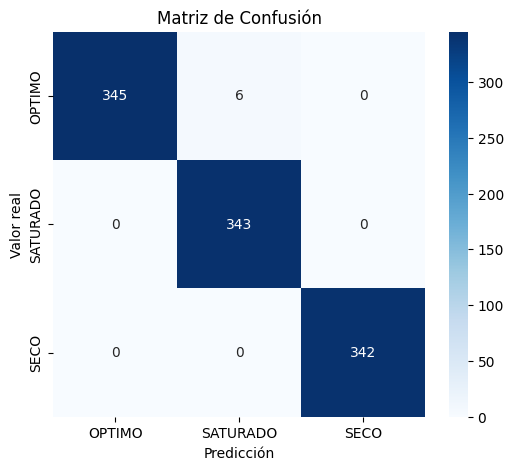

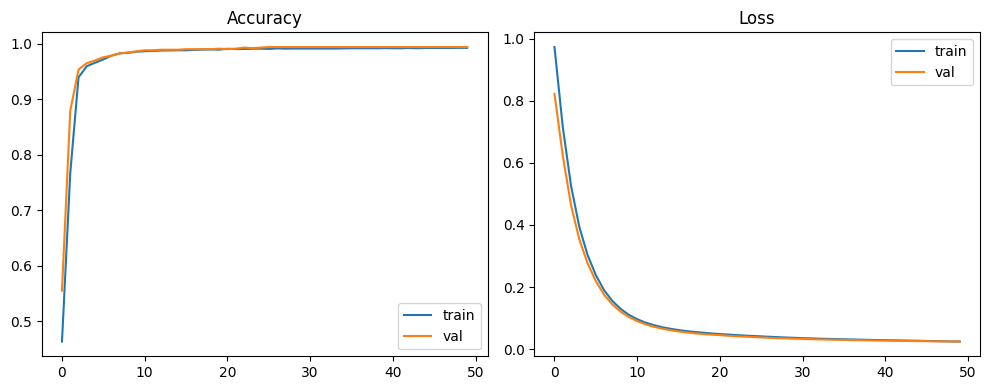

In [14]:
# Evalúa el modelo sobre el conjunto de prueba
y_pred_keras = modelo.predict(X_test_f_scaled).argmax(axis=1)

print(classification_report(y_test_f, y_pred_keras, target_names=le.classes_))

cm = confusion_matrix(y_test_f, y_pred_keras)
print(cm)

# Grafica la matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión')
plt.show()

# Grafica la evolución del entrenamiento
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(historial.history['accuracy'], label='train')
plt.plot(historial.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(historial.history['loss'], label='train')
plt.plot(historial.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## 7. Conversión a TensorFlow Lite

### 7.1 Conversión y cuantización int8

In [15]:
def representative_dataset():
    # Es recomendable usar solo una muestra representativa (ej. 100-500 datos)
    for i in range(len(X_train_f_scaled)):
        # El yield debe devolver una lista de tensores, uno por cada entrada del modelo
        yield [X_train_f_scaled[i:i+1].astype(np.float32)]

# 2. Configurar el conversor fuera de la función
converter = tf.lite.TFLiteConverter.from_keras_model(modelo)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# 3. Convertir y guardar
tflite_model = converter.convert()

with open('modelo_riego.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"Tamaño del modelo cuantizado: {len(tflite_model)} bytes")

Saved artifact at '/tmp/tmp9c_obme8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133919525936912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133919525938064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133919525936720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133919525934800: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Tamaño del modelo cuantizado: 2280 bytes


### 7.2 Validación del modelo cuantizado (TFLite Interpreter)

In [16]:
# Carga el modelo TensorFlow Lite para inspeccionar sus entradas y salidas
interpreter = tf.lite.Interpreter(model_path='modelo_riego.tflite')
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input details:", input_details)
print("Output details:", output_details)

# Obtiene los parámetros de cuantización necesarios para la inferencia en el ESP32
in_scale, in_zero = input_details[0]['quantization']
out_scale, out_zero = output_details[0]['quantization']

print(f"\nInput scale={in_scale}, zero_point={in_zero}")
print(f"Output scale={out_scale}, zero_point={out_zero}")

Input details: [{'name': 'serving_default_keras_tensor:0', 'index': 0, 'shape': array([1, 3], dtype=int32), 'shape_signature': array([-1,  3], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.01669207029044628, -27), 'quantization_parameters': {'scales': array([0.01669207], dtype=float32), 'zero_points': array([-27], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 7, 'shape': array([1, 3], dtype=int32), 'shape_signature': array([-1,  3], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]

Input scale=0.01669207029044628, zero_point=-27
Output scale=0.00390625, zero_point=-128


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 8. Exportación a array C (para PlatformIO)

In [17]:
# 1. Ejecutar el comando de sistema para convertir el archivo a formato C
!xxd -i modelo_riego.tflite > modelo_riego.h

# 2. Instrucciones de Python normales
print("Archivo modelo_riego.h generado.")

from google.colab import files

# 3. Descargar los archivos
files.download('modelo_riego.h')
files.download('modelo_riego.tflite')

Archivo modelo_riego.h generado.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>